# Las Olas de Calor Cambian 176% la Vida en el Océano

702.037 estimaciones de biomasa. 1.566 especies de peces. 29 años de datos. ¿Quién gana y quién pierde cuando el océano se calienta?

---

📄 **Paper:** Blowes *et al.* (2026). *Nature Ecology & Evolution*.
DOI: [10.1038/s41559-026-03013-5](https://doi.org/10.1038/s41559-026-03013-5)

▶️ **Video:** [Ver en YouTube](https://youtube.com/shorts/Pzn_RTumA3k)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-02-27-olas-calor-biomasa-peces-oceano/notebook.ipynb)

## El océano se calienta, ¿y los peces?

El océano se calienta de tres formas distintas: la tendencia de fondo (décadas), los años atípicamente cálidos, y las olas de calor marinas. Las tres amenazan a los peces — pero nadie había separado cuánto daño hace cada una.

Para responderlo, usaron FISHGLOB — una base de datos que reúne censos de arrastre científico de todo el mundo. **33.990 poblaciones de peces**, 1.566 especies, 29 años de muestreo en las principales cuencas del Hemisferio Norte.

La idea clave: cada población de peces tiene una **posición térmica** — si vive cerca del límite cálido de su especie (borde cálido) o cerca del límite frío (borde frío). Cuando el océano se calienta, las del borde frío podrían beneficiarse... y las del borde cálido, perder.

Veamos qué dicen los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_POSICION = 0.5      # Separar borde frío (<-0.5) de borde cálido (>0.5)
P_SIGNIFICATIVO = 0.05     # Umbral de significancia estadística
FUENTE = 'Fuente: Blowes et al. (2026), Nat. Ecol. Evol. | Datos: Supplementary Data S1'
COLOR_FRIO = '#2563EB'     # Azul CaM — borde frío (ganadores)
COLOR_CALIDO = '#DC2626'   # Rojo — borde cálido (perdedores)
COLOR_CENTRO = '#D97706'   # Amber — centro térmico
COLOR_SEC = '#059669'      # Emerald — datos secundarios

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos agregados
df_pos = pd.read_csv('datos/biomasa_por_posicion_termica.csv')
df_resumen = pd.read_csv('datos/resumen_por_estresor.csv')
df_dist = pd.read_csv('datos/distribucion_pendientes_temperatura.csv')
df_especies = pd.read_csv('datos/especies_extremas_mhw.csv')

print(f"Datos cargados:")
print(f"  Biomasa × posición térmica: {len(df_pos)} filas (10 bins × 4 estresores)")
print(f"  Resumen por estresor: {len(df_resumen)} filas")
print(f"  Distribución de pendientes: {len(df_dist)} filas")
print(f"  Especies extremas: {len(df_especies)} filas")
print(f"\nAgregado de 105.299 regresiones población-nivel")
print(f"({df_resumen['n_pop'].max():,.0f} poblaciones, ~{df_resumen['n_species'].max():,.0f} especies, 1993-2021)")

Datos cargados:
  Biomasa × posición térmica: 40 filas (10 bins × 4 estresores)
  Resumen por estresor: 4 filas
  Distribución de pendientes: 240 filas
  Especies extremas: 30 filas

Agregado de 105.299 regresiones población-nivel
(26,775 poblaciones, ~1,498 especies, 1993-2021)


## Ganadores y perdedores

Aquí está.

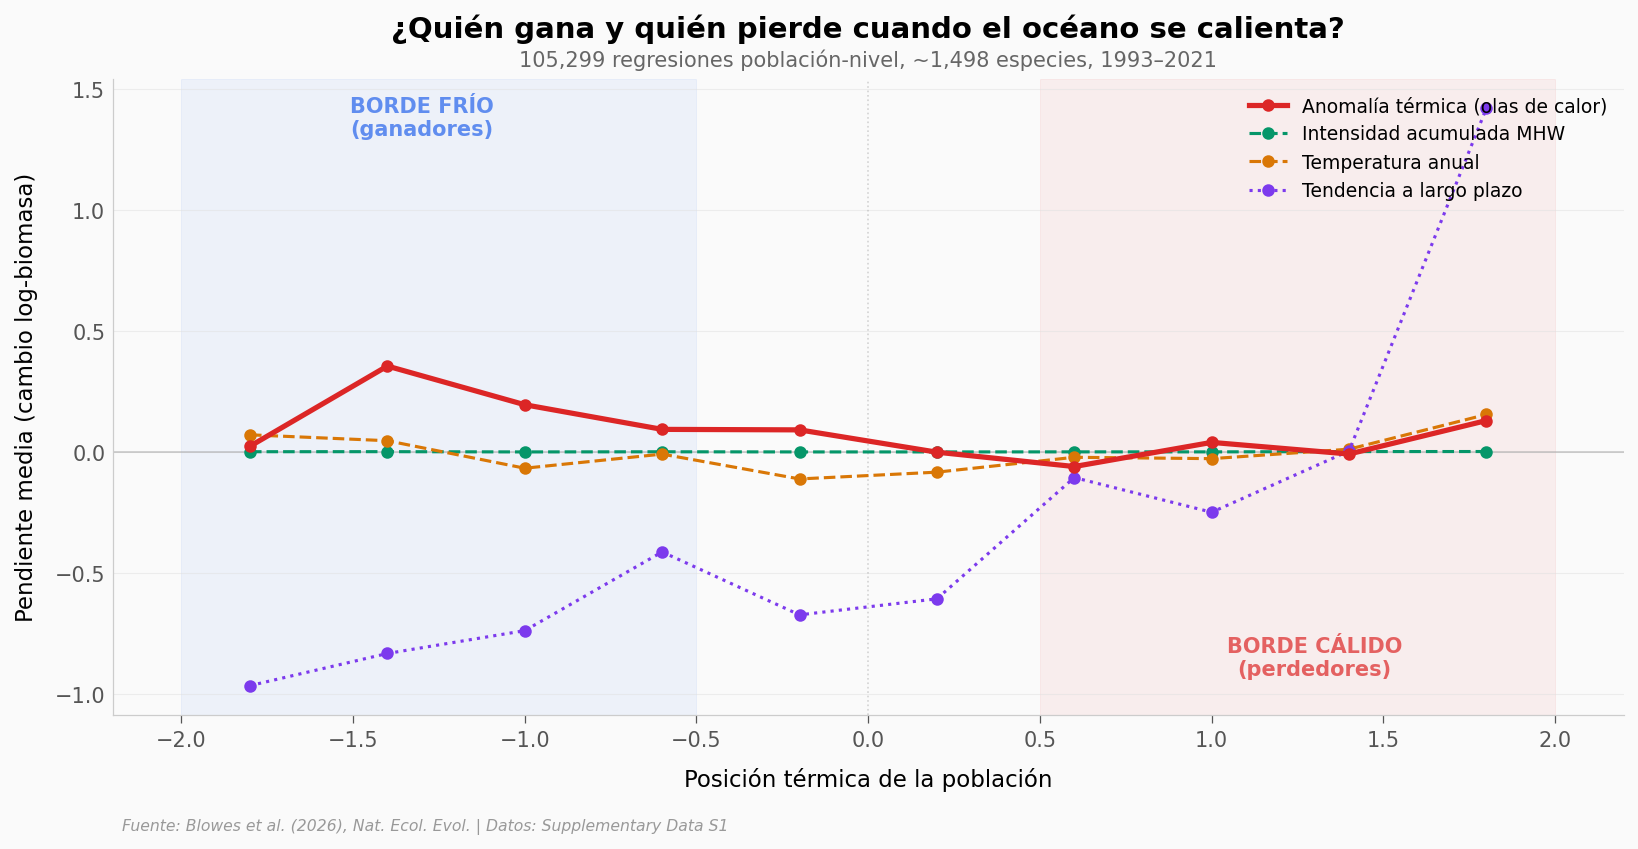

In [2]:
# Gráfica hero: pendiente media de biomasa vs posición térmica
fig, ax = plt.subplots(figsize=(13, 5.5))

stressor_config = {
    'Temperature difference': ('Anomalía térmica (olas de calor)', COLOR_CALIDO, 2.5, '-'),
    'Cumulative intensity':   ('Intensidad acumulada MHW', COLOR_SEC, 1.5, '--'),
    'Temperature':            ('Temperatura anual', COLOR_CENTRO, 1.5, '--'),
    'Temperature trend':      ('Tendencia a largo plazo', '#7C3AED', 1.5, ':'),
}

tp_bins = df_pos['tp_bin'].unique()
tp_vals = [float(b) for b in sorted(tp_bins)]

for stressor, (label, color, lw, ls) in stressor_config.items():
    sub = df_pos[df_pos['Thermal stressor'] == stressor].copy()
    sub['tp_val'] = sub['tp_bin'].astype(float)
    sub = sub.sort_values('tp_val')
    ax.plot(sub['tp_val'], sub['mean_slope'], color=color,
            linewidth=lw, linestyle=ls, marker='o', markersize=5,
            label=label, zorder=5 if stressor == 'Temperature difference' else 3)

ax.axhline(y=0, color='#999999', linewidth=0.8, linestyle='-', alpha=0.5)
ax.axvline(x=0, color='#999999', linewidth=0.8, linestyle=':', alpha=0.4)

# Zonas de borde
ax.axvspan(-2, -UMBRAL_POSICION, alpha=0.06, color=COLOR_FRIO)
ax.axvspan(UMBRAL_POSICION, 2, alpha=0.06, color=COLOR_CALIDO)

ax.text(-1.3, ax.get_ylim()[1]*0.85, 'BORDE FRÍO\n(ganadores)',
        fontsize=10, color=COLOR_FRIO, fontweight='bold', ha='center', alpha=0.7)
ax.text(1.3, ax.get_ylim()[0]*0.85, 'BORDE CÁLIDO\n(perdedores)',
        fontsize=10, color=COLOR_CALIDO, fontweight='bold', ha='center', alpha=0.7)

ax.set_xlabel('Posición térmica de la población', fontsize=11)
ax.set_ylabel('Pendiente media (cambio log-biomasa)', fontsize=11)
ax.set_title('¿Quién gana y quién pierde cuando el océano se calienta?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{df_resumen["n_pop"].sum():,.0f} regresiones población-nivel, ~{df_resumen["n_species"].max():,.0f} especies, 1993–2021',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ganadores_perdedores.png', dpi=200, bbox_inches='tight')
plt.show()

El patrón es claro para la **anomalía térmica** (línea roja): las poblaciones cerca del borde frío de su especie (izquierda) tienden a ganar biomasa cuando hay años más cálidos. Las del borde cálido (derecha) tienden a perder.

Según el modelo GAM completo del paper, las olas de calor están ligadas a pérdidas de hasta **43,4%** en el borde cálido y ganancias de hasta **176%** en el borde frío. Son los extremos del modelo — nuestros datos suplementarios muestran el gradiente subyacente: la pendiente media pasa de +0,35 (posición -1,4) a -0,06 (posición +0,6).

La **tendencia a largo plazo** (línea violeta punteada) es mayoritariamente negativa — el calentamiento sostenido va de la mano con pérdida de biomasa en 8 de 10 posiciones térmicas. Solo las poblaciones en el extremo más cálido (posición ≥1,4) escapan a este patrón, aunque con bajo n en esas posiciones.

## ¿Cuántas poblaciones ganan vs pierden?

La pendiente media esconde mucha variación. ¿Cuántas poblaciones realmente ganan?

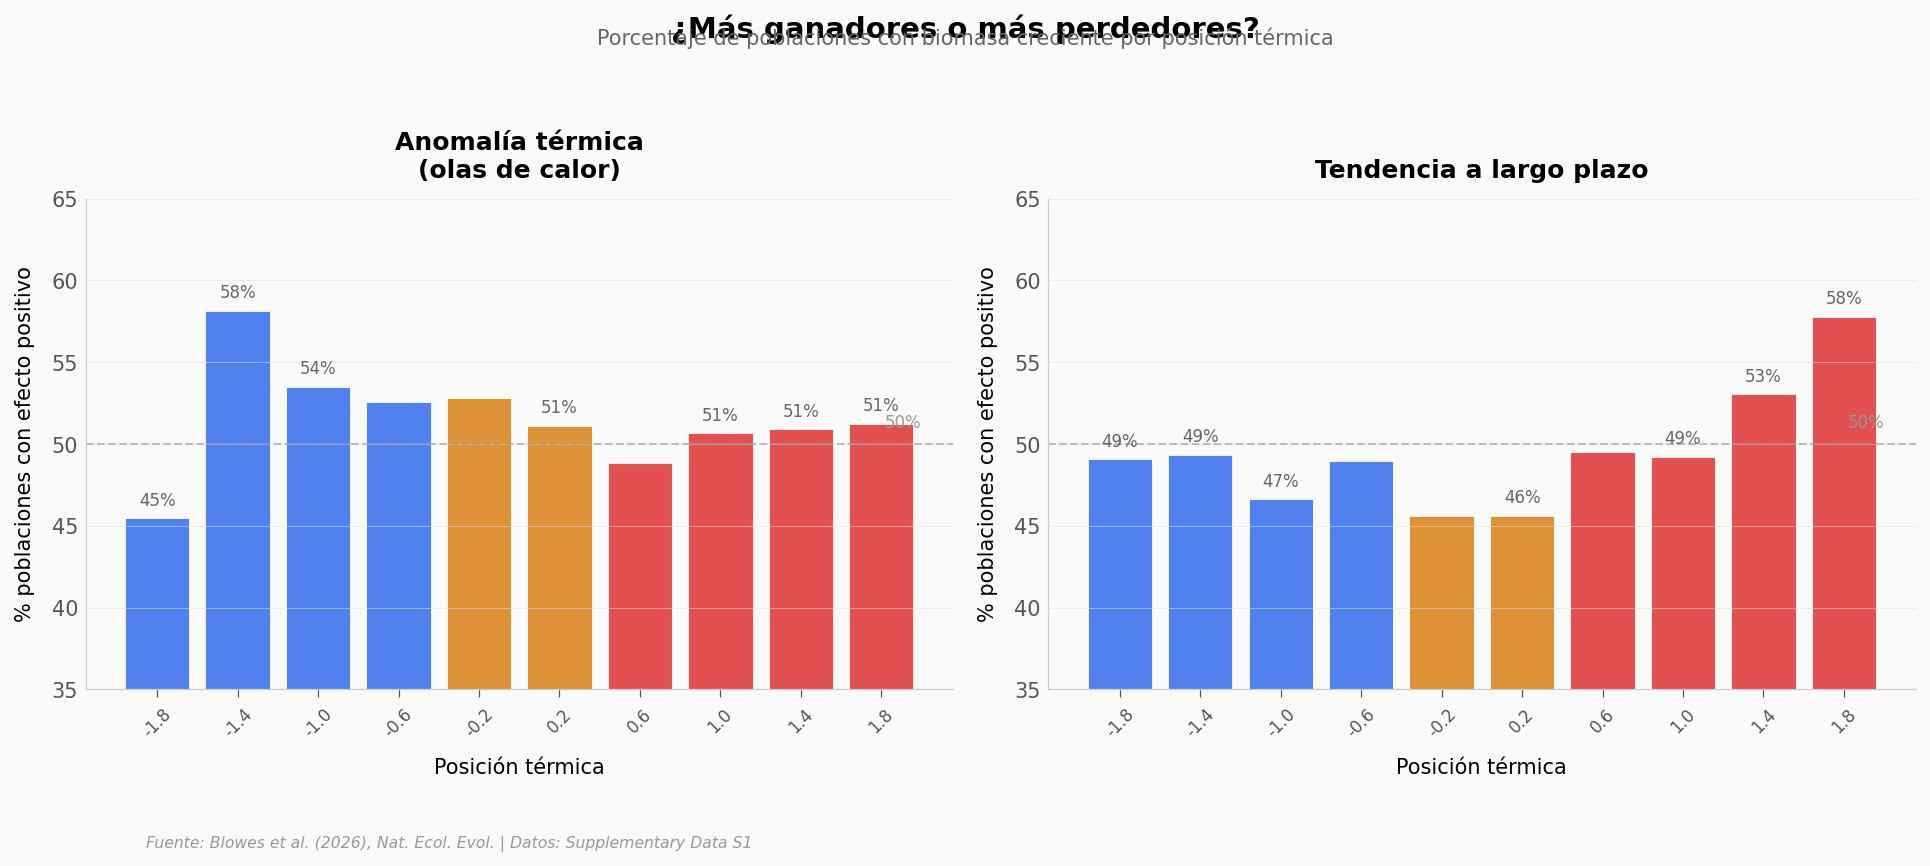

In [3]:
# Porcentaje de poblaciones con efecto positivo por posición térmica
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, stressor, title in [
    (axes[0], 'Temperature difference', 'Anomalía térmica\n(olas de calor)'),
    (axes[1], 'Temperature trend', 'Tendencia a largo plazo')
]:
    sub = df_pos[df_pos['Thermal stressor'] == stressor].copy()
    sub['tp_val'] = sub['tp_bin'].astype(float)
    sub = sub.sort_values('tp_val')

    colors = [COLOR_FRIO if v < -UMBRAL_POSICION
              else COLOR_CALIDO if v > UMBRAL_POSICION
              else COLOR_CENTRO for v in sub['tp_val']]

    bars = ax.bar(range(len(sub)), sub['pct_positive'], color=colors, alpha=0.8,
                  edgecolor='white', linewidth=0.5)

    ax.axhline(y=50, color='#999999', linewidth=1, linestyle='--', alpha=0.6)
    ax.text(len(sub)-0.5, 51, '50%', fontsize=8, color='#999999', ha='right')

    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels([f'{v:.1f}' for v in sub['tp_val']], fontsize=8, rotation=45)
    ax.set_xlabel('Posición térmica', fontsize=10)
    ax.set_ylabel('% poblaciones con efecto positivo', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylim(35, 65)

    # Annotate key values
    for i, (_, row) in enumerate(sub.iterrows()):
        if abs(row['tp_val']) >= 1.0 or row['tp_val'] == 0.2:
            ax.text(i, row['pct_positive'] + 0.8, f"{row['pct_positive']:.0f}%",
                    fontsize=8, ha='center', color='#666666')

fig.suptitle('¿Más ganadores o más perdedores?',
             fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'Porcentaje de poblaciones con biomasa creciente por posición térmica',
         fontsize=10, color='#666666', ha='center')
plt.tight_layout()
fig.text(0.08, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/porcentaje_positivos.png', dpi=200, bbox_inches='tight')
plt.show()

Para la anomalía térmica (izquierda), el gradiente es visible: en el borde frío (posición -1,4), un 58% de las poblaciones muestra efectos positivos. En el borde cálido (posición +0,6), baja al 49%. No es un efecto masivo en promedio — pero se amplifica en las colas de la distribución.

Para la tendencia a largo plazo (derecha), la señal es más sutil. La mayoría de posiciones están por debajo del 50% — el calentamiento sostenido se asocia con pérdida de biomasa casi universal.

## Los extremos: ganadores y perdedores con nombre propio

¿Qué especies están en las colas?

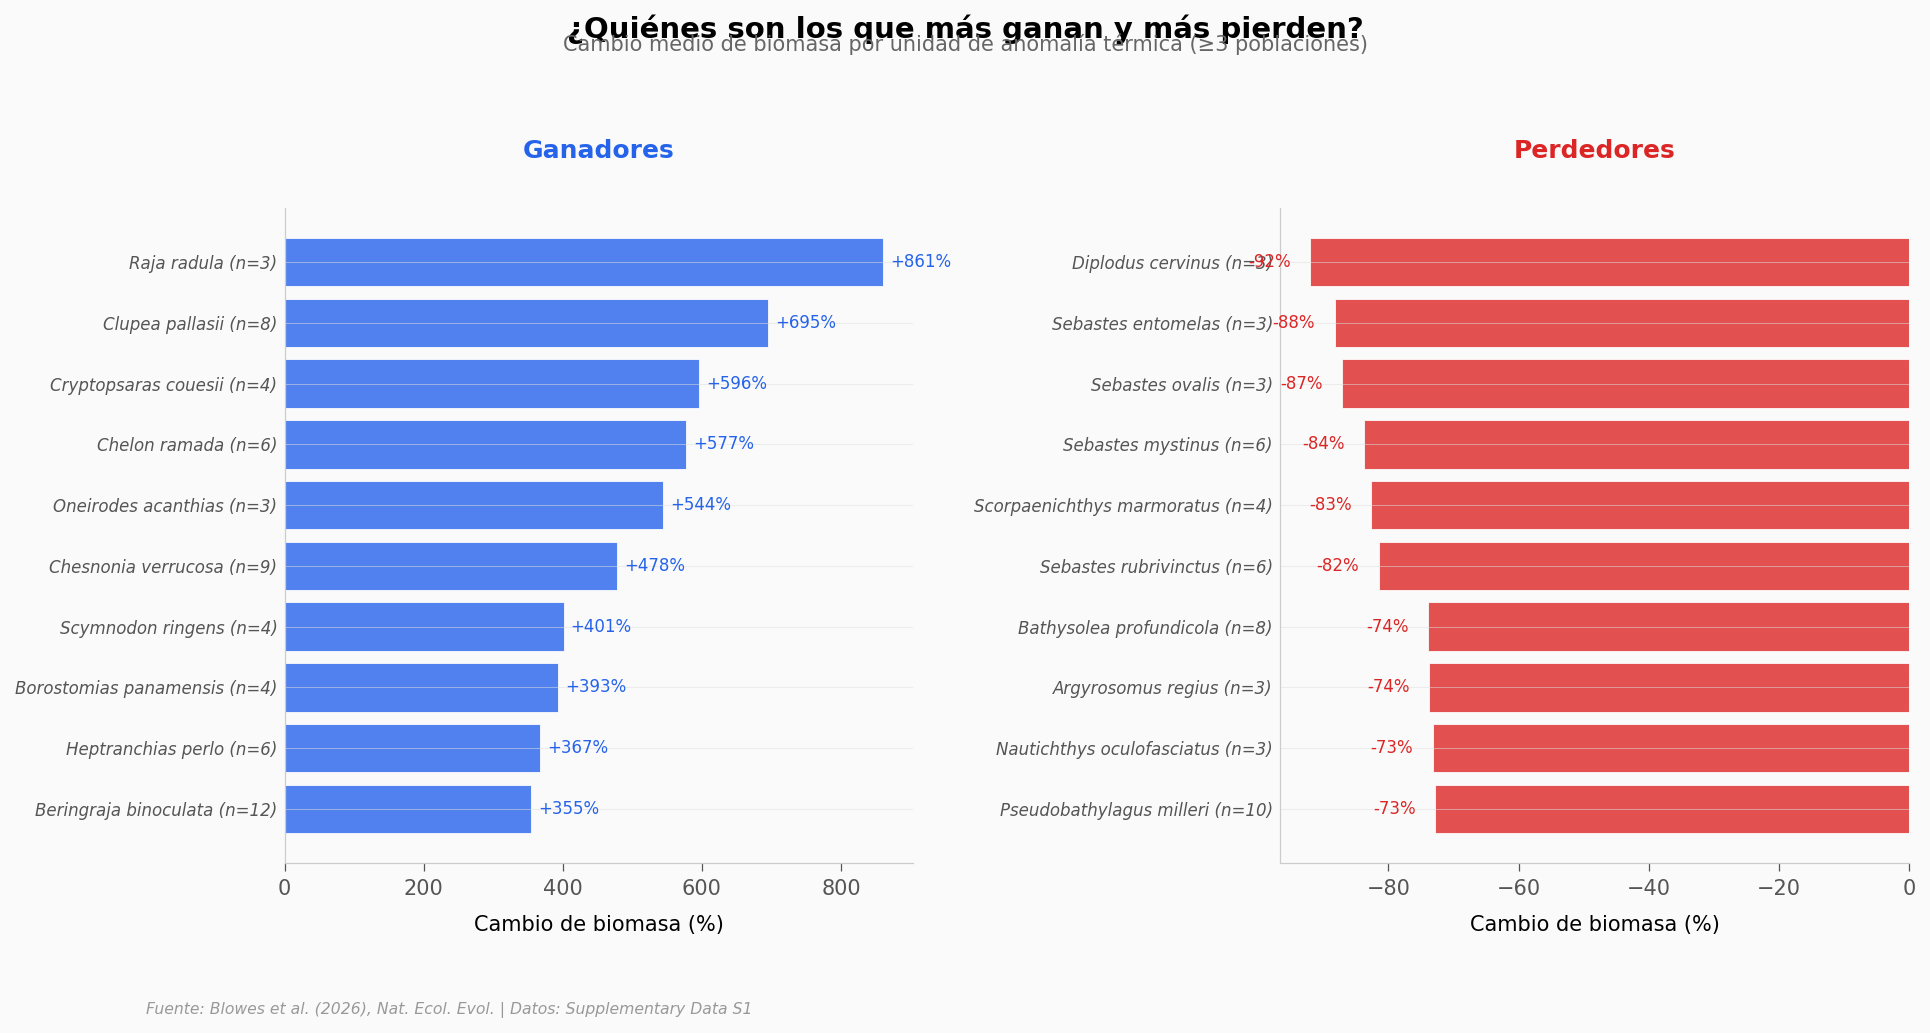

In [4]:
# Top 10 ganadores y perdedores (temperatura diferencial, ≥3 poblaciones)
winners = df_especies.nlargest(10, 'slope_pct')
losers = df_especies.nsmallest(10, 'slope_pct')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Ganadores
bars1 = ax1.barh(range(len(winners)), winners['slope_pct'].values,
                 color=COLOR_FRIO, alpha=0.8, edgecolor='white', linewidth=0.5)
ax1.set_yticks(range(len(winners)))
ax1.set_yticklabels([f"{s} (n={int(n)})" for s, n in
                     zip(winners['Species'].values, winners['n_pop'].values)],
                    fontsize=8, style='italic')
ax1.set_xlabel('Cambio de biomasa (%)', fontsize=10)
ax1.set_title('Ganadores', fontsize=12, fontweight='bold', color=COLOR_FRIO)
for i, v in enumerate(winners['slope_pct'].values):
    ax1.text(v + 10, i, f'+{v:.0f}%', fontsize=8, va='center', color=COLOR_FRIO)
ax1.invert_yaxis()

# Perdedores
bars2 = ax2.barh(range(len(losers)), losers['slope_pct'].values,
                 color=COLOR_CALIDO, alpha=0.8, edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(len(losers)))
ax2.set_yticklabels([f"{s} (n={int(n)})" for s, n in
                     zip(losers['Species'].values, losers['n_pop'].values)],
                    fontsize=8, style='italic')
ax2.set_xlabel('Cambio de biomasa (%)', fontsize=10)
ax2.set_title('Perdedores', fontsize=12, fontweight='bold', color=COLOR_CALIDO)
for i, v in enumerate(losers['slope_pct'].values):
    ax2.text(v - 3, i, f'{v:.0f}%', fontsize=8, va='center', ha='right', color=COLOR_CALIDO)
ax2.invert_yaxis()

fig.suptitle('¿Quiénes son los que más ganan y más pierden?',
             fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'Cambio medio de biomasa por unidad de anomalía térmica (≥3 poblaciones)',
         fontsize=10, color='#666666', ha='center')
plt.tight_layout()
fig.text(0.08, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/especies_extremas.png', dpi=200, bbox_inches='tight')
plt.show()

*Raja radula* (raya áspera) encabeza la lista: +861% de biomasa por cada grado de anomalía. En el otro extremo, *Diplodus cervinus* (sargo breado) pierde un 92%.

Pero estos son promedios por especie. Dentro de cada especie hay enorme variación entre poblaciones. ¿Cómo se distribuyen las pendientes?

## ¿Qué tan anómala es la situación?

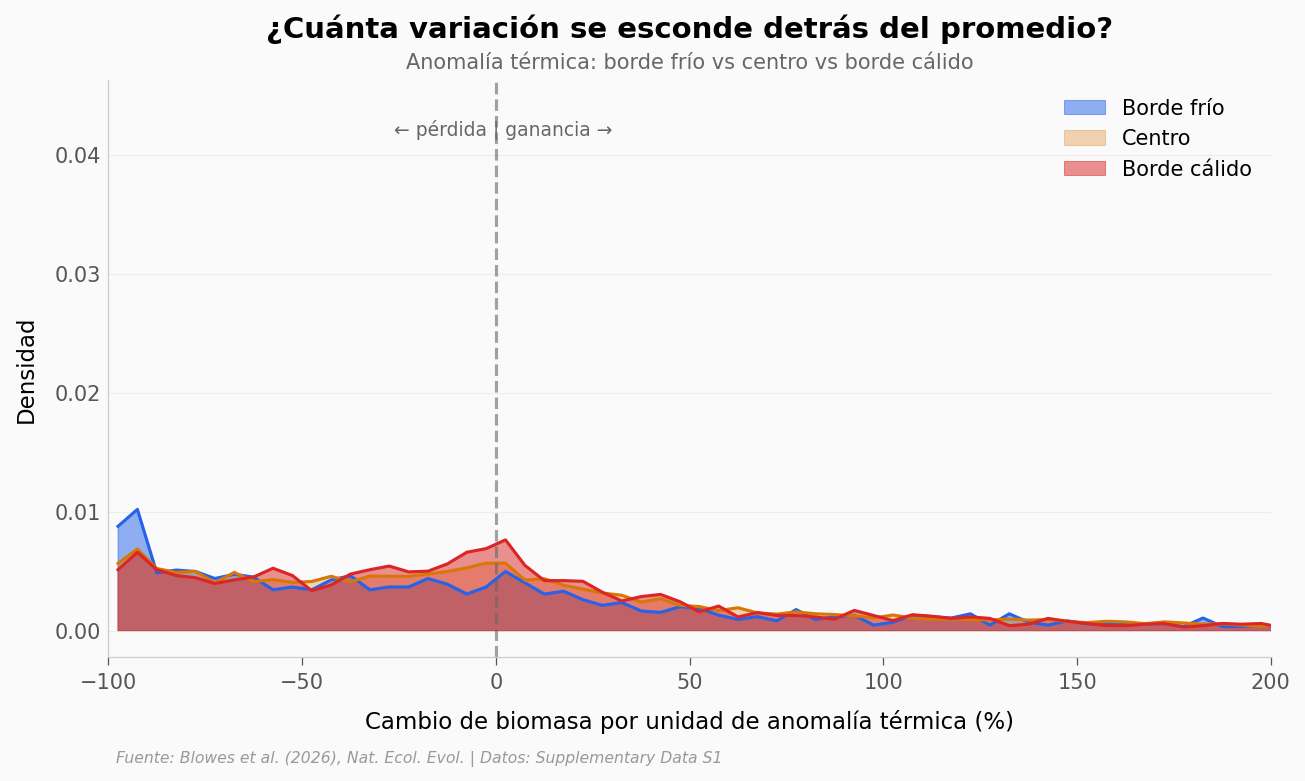

In [5]:
# Distribución de pendientes: borde frío vs centro vs borde cálido
fig, ax = plt.subplots(figsize=(10, 5))

edge_config = {
    'Borde frío': (COLOR_FRIO, 0.5),
    'Centro': (COLOR_CENTRO, 0.3),
    'Borde cálido': (COLOR_CALIDO, 0.5),
}

for edge, (color, alpha) in edge_config.items():
    sub = df_dist[df_dist['edge'] == edge]
    # Normalizar a densidad para comparar (diferentes n)
    total = sub['count'].sum()
    if total > 0:
        density = sub['count'] / total / (sub['slope_pct_center'].diff().median())
        ax.fill_between(sub['slope_pct_center'], density, alpha=alpha, color=color, label=edge)
        ax.plot(sub['slope_pct_center'], density, color=color, linewidth=1.5)

ax.axvline(x=0, color='#666666', linewidth=1.5, linestyle='--', alpha=0.6)
ax.text(2, ax.get_ylim()[1]*0.9, '← pérdida | ganancia →',
        fontsize=9, color='#666666', ha='center')

ax.set_xlabel('Cambio de biomasa por unidad de anomalía térmica (%)', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title('¿Cuánta variación se esconde detrás del promedio?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Anomalía térmica: borde frío vs centro vs borde cálido',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.set_xlim(-100, 200)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_pendientes.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Pérdida de biomasa hasta 43,4% en borde cálido | ⚠️ Parcial | El paper reporta este valor del modelo GAM completo. Nuestros datos muestran el gradiente: pendiente media negativa (-0,06) en el borde cálido. Los datos suplementarios contienen las pendientes, no las predicciones del GAM |
| Ganancia hasta 176% en borde frío | ⚠️ Parcial | Mismo caso: valor del modelo GAM. Nuestros datos muestran pendiente positiva (+0,35) en posición -1,4, consistente con la dirección |
| Calentamiento a largo plazo se asocia con declive generalizado | ✅ Sí | La tendencia a largo plazo muestra pendientes negativas en 8 de 10 bins de posición térmica. Solo 46,6% de poblaciones muestra efecto positivo |
| Patrón de "ganadores y perdedores" según posición térmica | ✅ Sí | Spearman ρ = -0,033 (p < 0,001) para anomalía térmica vs pendiente. Débil pero significativo con n = 26.428 |
| Las olas de calor tienen el mayor efecto a corto plazo | ✅ Sí | El 5,6% de poblaciones muestra efecto significativo (p < 0,05) con anomalía térmica, vs 3,9% (intensidad), 1,7% (temperatura), 0,5% (tendencia) |

> **Limitaciones:**
> - Los datos suplementarios contienen pendientes de regresión por población, no las predicciones del modelo GAM completo del paper. Los valores headline (176%, 43,4%, 19,8%) no son directamente reproducibles desde estos datos
> - Solo cubrimos el Hemisferio Norte — los patrones pueden diferir en el Hemisferio Sur
> - Spearman ρ = -0,033 es estadísticamente significativo por el gran n, pero el tamaño del efecto es pequeño
> - Las posiciones térmicas extremas (>|1,5|) tienen pocas observaciones (<100), limitando la fiabilidad en las colas

## Ahora tú

1. **¿Cuáles son las especies con más poblaciones?** Filtra `df_especies` por `n_pop` y mira si las especies con más datos muestran patrones más claros que las de pocas poblaciones

2. **¿Cambia el patrón si subes el umbral de significancia?** Prueba con `P_SIGNIFICATIVO = 0.01` — ¿se concentran los resultados significativos en algún extremo de posición térmica?

3. **¿Qué estresor muestra la mayor variación entre bins?** Calcula `df_pos.groupby('Thermal stressor')['pct_positive'].std()` — el estresor con más variación es el que mejor discrimina entre ganadores y perdedores

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Hay relación entre el tamaño de la muestra (n_pop) y la magnitud del efecto?
# Las especies con muchas poblaciones podrían mostrar señales más robustas

from scipy import stats

# Correlación entre número de poblaciones y pendiente absoluta
rho, p = stats.spearmanr(df_especies['n_pop'], df_especies['slope_pct'].abs())
print(f"Spearman ρ (n poblaciones vs |efecto|): {rho:.3f}, p = {p:.4f}")
print(f"  → {'Relación significativa' if p < 0.05 else 'Sin relación significativa'}")
print(f"     Más poblaciones {'= efectos menores (regresión a la media)' if rho < 0 else '= efectos mayores'}")

print(f"\nEspecies con más poblaciones y efecto extremo:")
extremas = df_especies[df_especies['n_pop'] >= 10].sort_values('slope_pct')
print(f"  Peor perdedor: {extremas.iloc[0]['Species']} "
      f"({extremas.iloc[0]['slope_pct']:.0f}%, n={int(extremas.iloc[0]['n_pop'])} pob.)")
print(f"  Mejor ganador: {extremas.iloc[-1]['Species']} "
      f"({extremas.iloc[-1]['slope_pct']:.0f}%, n={int(extremas.iloc[-1]['n_pop'])} pob.)")

Spearman ρ (n poblaciones vs |efecto|): 0.054, p = 0.7771
  → Sin relación significativa
     Más poblaciones = efectos mayores

Especies con más poblaciones y efecto extremo:
  Peor perdedor: Pseudobathylagus milleri (-73%, n=10 pob.)
  Mejor ganador: Beringraja binoculata (355%, n=12 pob.)


---

## Créditos

- **Paper:** Blowes *et al.* (2026). Long-term ocean warming, interannual temperature variability and marine heatwaves [...]. *Nature Ecology & Evolution*. DOI: [10.1038/s41559-026-03013-5](https://doi.org/10.1038/s41559-026-03013-5)
- **Datos:** Supplementary Data S1 (MOESM4), disponible en Nature.com
- **Licencia datos:** CC BY 4.0 (según política de Nature)
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)